In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Práctica: Análisis y Reducción de Dimensionalidad con UMAP

### Descripción:
Aplicaremos el mismo enfoque incremental utilizado en PCA, LDA, y t-SNE, para analizar cómo la reducción de dimensionalidad con UMAP afecta a los modelos de clasificación.

### Dataset:
El dataset `Wine` contiene 13 características químicas que describen el contenido de varios vinos, y está clasificado en 3 tipos de vinos diferentes. Las características incluyen:
- Alcohol
- Ácido málico
- Cenizas
- Alcalinidad de las cenizas
- Magnesio
- Fenoles totales
- Flavonoides
- Fenoles no flavonoides
- Proantocianinas
- Intensidad de color
- Tono
- OD280/OD315 de vinos diluidos
- Prolina




## Etapa 1: Exploración de los datos

### Objetivo:
Explorar el dataset que vamos a utilizar con **UMAP**.

### Instrucciones:
1. Cargar el conjunto de datos `Wine` disponible en `sklearn`.
2. Mostrar las primeras filas del dataset y las características.
3. Visualizar la distribución de las clases.

### Visualizaciones:
- **Distribución de las clases** en el conjunto de datos.


Aquí cargaremos el dataset de Wine y realizaremos un análisis exploratorio básico.

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

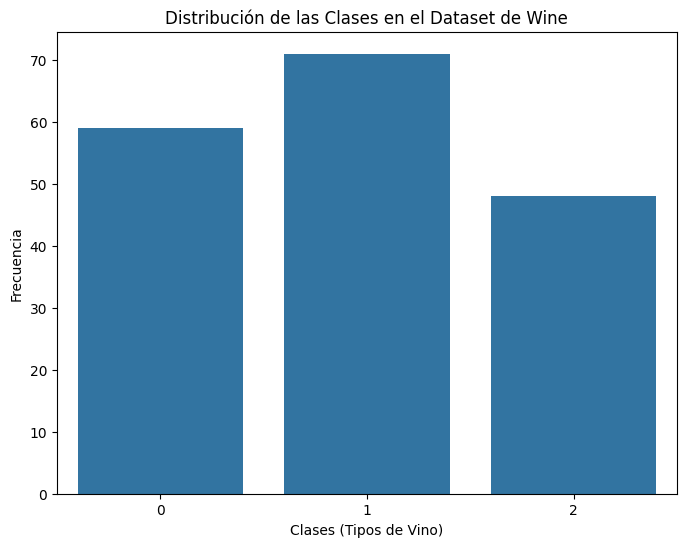

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Cargar el dataset de Wine
wine_data = load_wine()
X_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine = wine_data.target

# Mostrar las primeras filas del dataset
print(X_wine.head())

# Mostrar la distribución de las clases
plt.figure(figsize=(8, 6))
sns.countplot(x=y_wine)
plt.title("Distribución de las Clases en el Dataset de Wine")
plt.xlabel("Clases (Tipos de Vino)")
plt.ylabel("Frecuencia")
plt.show()

## Etapa 2: Aplicación de UMAP

### Objetivo:
Aplicar **UMAP** al conjunto de datos para reducir las dimensiones a un espacio de 2 y 3 dimensiones, y visualizar las relaciones entre las clases.

### Instrucciones:
1. Aplicar **UMAP** para reducir las dimensiones del conjunto de datos a 2 y 3 dimensiones.
2. Visualizar las proyecciones en 2D y 3D.
3. Analizar la separación entre las clases.

### Visualizaciones:
- **Proyección en 2D con UMAP**.
- **Proyección en 3D con UMAP**.


¡Es necesario tener instalada la librería de UMAP!

In [3]:
pip install umap-learn

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 3.4 MB/s eta 0:00:01
   --------------------------- ------------ 1.8/2.7 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 5.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   -- ------------------------------------- 1.6/28.1 MB 9.3 MB/s eta 0:00:03
   ----- ---------------------------------- 3.9/28.1 MB 9.8 MB/s eta 0:00:03
   -------- ------------------------------- 6.3/28.1 MB 10.4 MB/s eta 0:00:03
   ------------ --------------------------- 8.9/28.1 MB 11.1 MB/s eta 0:00:02
   ---------------- ----------------------- 11.5/28.1 MB 11.4 MB/s eta 0:00:02
   -------------------- ------------------- 14.7/28.1 MB 12.1 MB/s eta 0:00:02
   ------------------------ --------------- 17.0/28.1 MB 12.1 MB/s eta 0:00:01
   --------------------------- ------------ 19.7/28.1 MB 12.0 MB/s eta 0:00:01
   ----

c:\Users\MATIA\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\MATIA\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


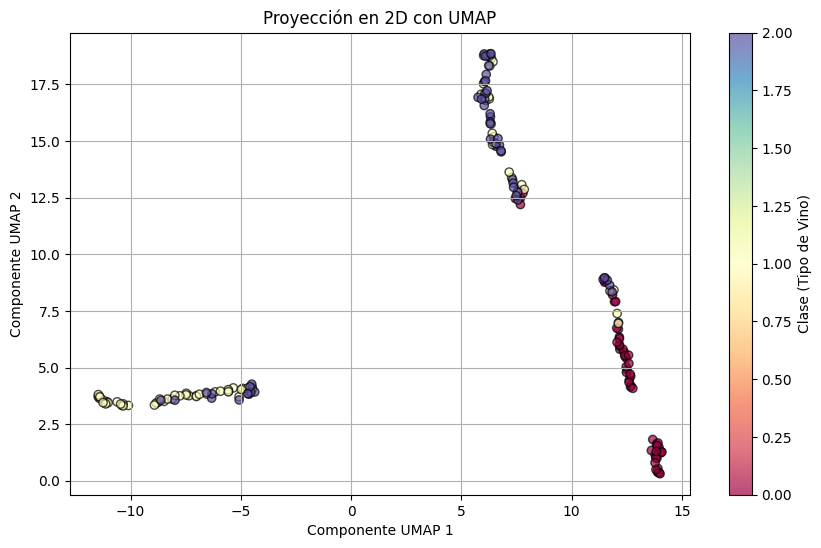

In [4]:
# Importar UMAP
import umap

# Aplicar UMAP para reducir a 2 dimensiones
umap_2d = umap.UMAP(n_components=2, random_state=42)
X_umap_2d = umap_2d.fit_transform(X_wine)

# Visualización de la proyección en 2D con UMAP
plt.figure(figsize=(10, 6))
plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=y_wine, cmap='Spectral', edgecolor='k', alpha=0.7)
plt.title('Proyección en 2D con UMAP')
plt.xlabel('Componente UMAP 1')
plt.ylabel('Componente UMAP 2')
plt.colorbar(label='Clase (Tipo de Vino)')
plt.grid(True)
plt.show()

c:\Users\MATIA\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


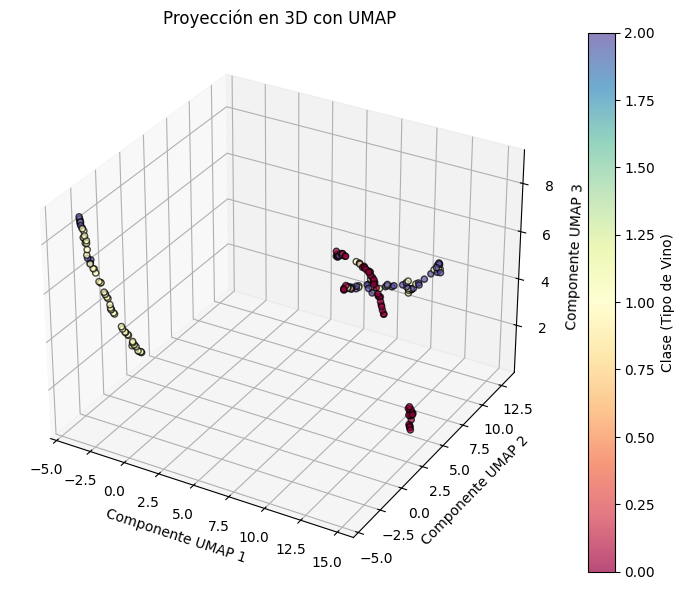

In [5]:
# Aplicar UMAP para reducir a 3 dimensiones
umap_3d = umap.UMAP(n_components=3, random_state=42)
X_umap_3d = umap_3d.fit_transform(X_wine)

# Visualización de la proyección en 3D con UMAP
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=y_wine, cmap='Spectral', edgecolor='k', alpha=0.7)

# Títulos y etiquetas
ax.set_title('Proyección en 3D con UMAP')
ax.set_xlabel('Componente UMAP 1')
ax.set_ylabel('Componente UMAP 2')
ax.set_zlabel('Componente UMAP 3')

# Mostrar la barra de colores para representar las clases
plt.colorbar(sc, label='Clase (Tipo de Vino)')
plt.show()

## Etapa 3: Entrenamiento de Modelos de Clasificación sin UMAP

### Objetivo:
Entrenar modelos de clasificación utilizando todas las características originales del conjunto de datos sin aplicar LDA. Estos resultados servirán como referencia para comparar el rendimiento después de aplicar UMAP.

### Instrucciones:
1. Entrenar los siguientes modelos de clasificación:
   - **Regresión Logística**
   - **Árbol de Decisión**
   - **Random Forest**
2. Evaluar el rendimiento de cada modelo utilizando:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
3. Mostrar la **matriz de confusión** y el **reporte de clasificación** para cada modelo.
4. Comparar los resultados obtenidos.

### Visualizaciones:
- **Matriz de Confusión**: Para analizar el rendimiento del modelo en cada clase.
- **Reporte de Clasificación**: Para observar precisión, recall y F1-score por clase.


--- Logistic Regression ---
Accuracy: 0.9815
Precision: 0.9823
Recall: 0.9815
F1 Score: 0.9814


c:\Users\MATIA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


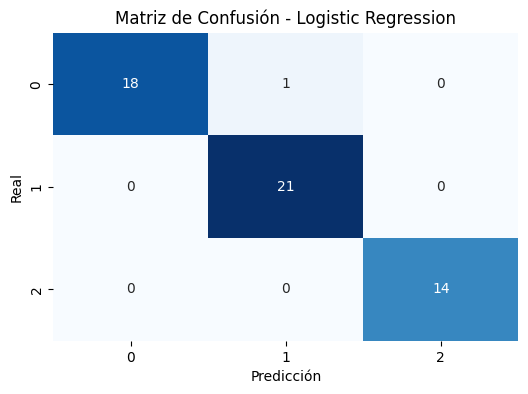

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      0.95      0.97        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



--- Decision Tree ---
Accuracy: 0.9630
Precision: 0.9638
Recall: 0.9630
F1 Score: 0.9628


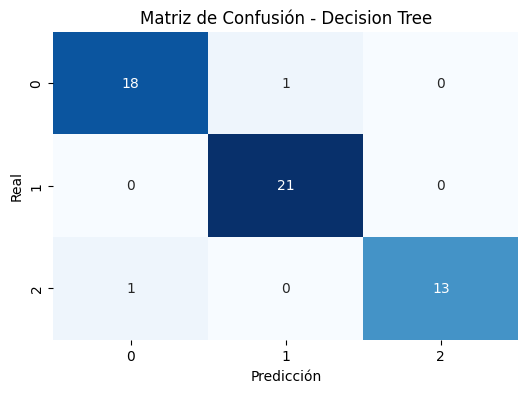

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



--- Random Forest ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


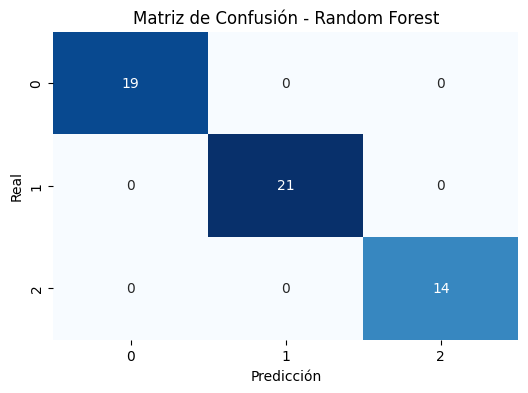

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54





In [6]:
# Importar las bibliotecas necesarias
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
# Dividir los datos en entrenamiento y prueba (para uso posterior)
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.3, random_state=42)

# Definir los modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    print(f"--- {name} ---")
    
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Predicción
    y_pred = model.predict(X_test)
    
    # Mostrar métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Matriz de confusión
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    
    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=wine_data.target_names))
    print("\n")


## Etapa 4: Entrenamiento de Modelos de Clasificación con UMAP

### Objetivo:
Entrenar los modelos de clasificación utilizando las proyecciones de **UMAP** y comparar los resultados con los obtenidos sin reducción de dimensionalidad.

### Instrucciones:
1. Aplicar **UMAP** para reducir las dimensiones del conjunto de datos.
2. Entrenar los siguientes modelos de clasificación utilizando las proyecciones de **UMAP**:
   - **Regresión Logística**
   - **Árbol de Decisión**
   - **Random Forest**
3. Evaluar el rendimiento de cada modelo utilizando:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
4. Mostrar la **matriz de confusión** y el **reporte de clasificación** para cada modelo.


--- Logistic Regression (con UMAP) ---
Accuracy: 0.7778
Precision: 0.7943
Recall: 0.7778
F1 Score: 0.7781


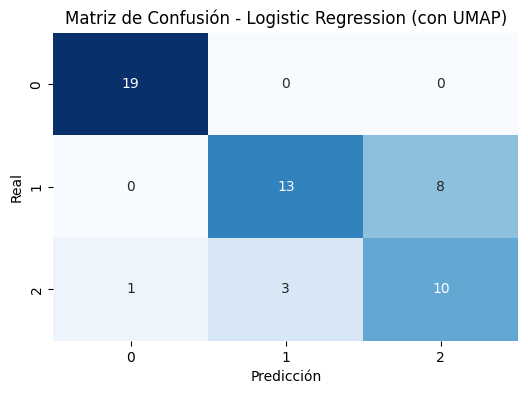

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       0.81      0.62      0.70        21
     class_2       0.56      0.71      0.62        14

    accuracy                           0.78        54
   macro avg       0.77      0.78      0.77        54
weighted avg       0.79      0.78      0.78        54



--- Decision Tree (con UMAP) ---
Accuracy: 0.7037
Precision: 0.7177
Recall: 0.7037
F1 Score: 0.7034


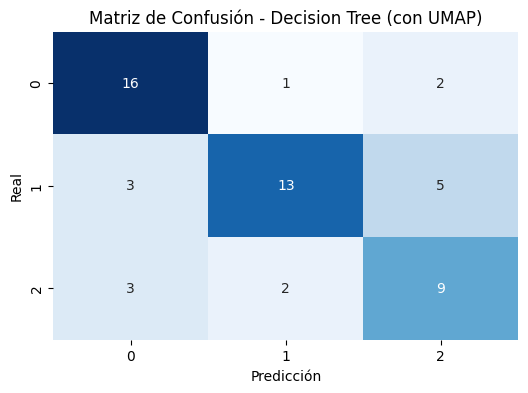

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.73      0.84      0.78        19
     class_1       0.81      0.62      0.70        21
     class_2       0.56      0.64      0.60        14

    accuracy                           0.70        54
   macro avg       0.70      0.70      0.69        54
weighted avg       0.72      0.70      0.70        54



--- Random Forest (con UMAP) ---
Accuracy: 0.7778
Precision: 0.7735
Recall: 0.7778
F1 Score: 0.7740


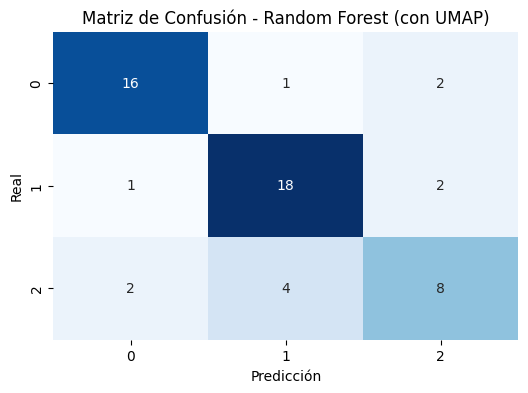

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.84      0.84      0.84        19
     class_1       0.78      0.86      0.82        21
     class_2       0.67      0.57      0.62        14

    accuracy                           0.78        54
   macro avg       0.76      0.76      0.76        54
weighted avg       0.77      0.78      0.77        54





In [7]:
# Usar las proyecciones de UMAP para entrenar los modelos
X_train_umap, X_test_umap, y_train, y_test = train_test_split(X_umap_2d, y_wine, test_size=0.3, random_state=42)

# Entrenar y evaluar cada modelo usando las proyecciones obtenidas por UMAP
for name, model in models.items():
    print(f"--- {name} (con UMAP) ---")
    
    # Entrenar el modelo
    model.fit(X_train_umap, y_train)
    
    # Predicción
    y_pred_umap = model.predict(X_test_umap)
    
    # Mostrar métricas
    accuracy = accuracy_score(y_test, y_pred_umap)
    precision = precision_score(y_test, y_pred_umap, average='weighted')
    recall = recall_score(y_test, y_pred_umap, average='weighted')
    f1 = f1_score(y_test, y_pred_umap, average='weighted')
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Matriz de confusión
    conf_matrix_umap = confusion_matrix(y_test, y_pred_umap)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_umap, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {name} (con UMAP)')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    
    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred_umap, target_names=wine_data.target_names))
    print("\n")


## Etapa 5: Comparación de Resultados con y sin UMAP

### Objetivo:
Comparar el rendimiento de los modelos de clasificación entrenados sin reducción de dimensionalidad (**Etapa 3**) con los modelos entrenados después de aplicar **UMAP** (**Etapa 4**).

### Instrucciones:
1. Comparar las métricas de rendimiento (**accuracy**, **precision**, **recall**, **F1-score**) para los modelos entrenados con y sin **UMAP**.
2. Visualizar la comparación en gráficos.
3. Analizar si la reducción de dimensionalidad mediante **UMAP** ha mejorado o empeorado el rendimiento de los modelos.

### Visualizaciones:
- Gráficos de barras comparativos que muestren las métricas (accuracy, precision, recall, F1-score) para cada modelo con y sin **UMAP**.


c:\Users\MATIA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


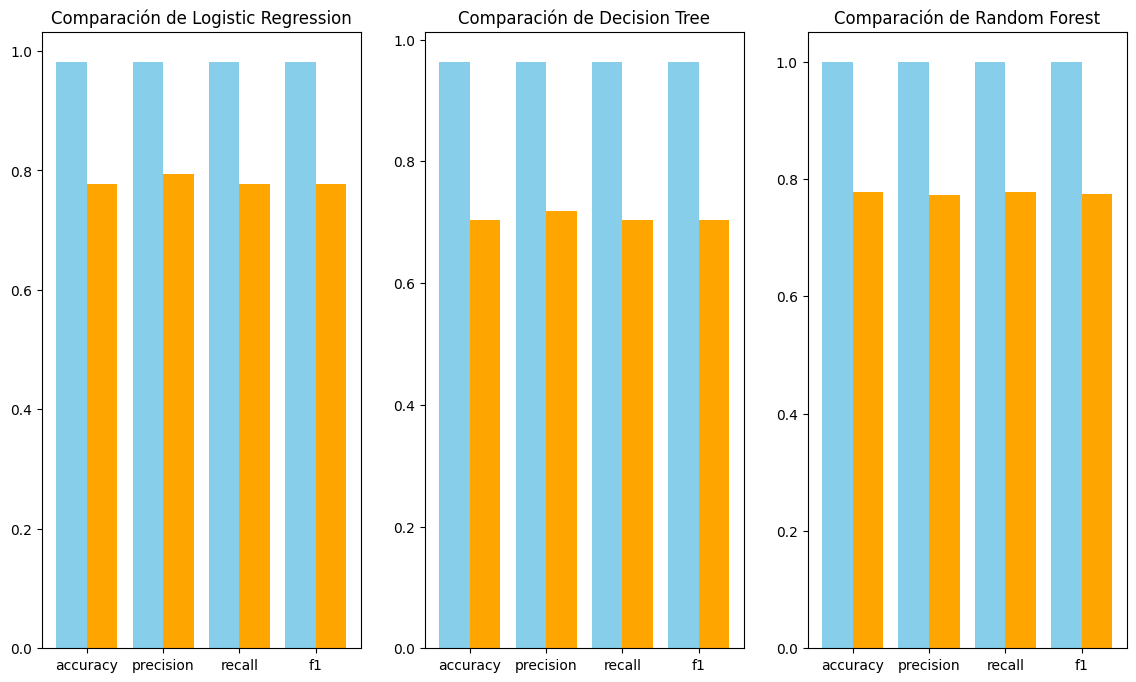

In [9]:
import numpy as np

# Definir las métricas obtenidas sin UMAP y con UMAP
results_umap = {
    'Logistic Regression': {'no_umap': {}, 'umap': {}},
    'Decision Tree': {'no_umap': {}, 'umap': {}},
    'Random Forest': {'no_umap': {}, 'umap': {}}
}

# Entrenar y almacenar los resultados sin UMAP (Etapa 3)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results_umap[name]['no_umap']['accuracy'] = accuracy_score(y_test, y_pred)
    results_umap[name]['no_umap']['precision'] = precision_score(y_test, y_pred, average='weighted')
    results_umap[name]['no_umap']['recall'] = recall_score(y_test, y_pred, average='weighted')
    results_umap[name]['no_umap']['f1'] = f1_score(y_test, y_pred, average='weighted')

# Entrenar y almacenar los resultados con UMAP (Etapa 4)
for name, model in models.items():
    model.fit(X_train_umap, y_train)
    y_pred_umap = model.predict(X_test_umap)
    
    results_umap[name]['umap']['accuracy'] = accuracy_score(y_test, y_pred_umap)
    results_umap[name]['umap']['precision'] = precision_score(y_test, y_pred_umap, average='weighted')
    results_umap[name]['umap']['recall'] = recall_score(y_test, y_pred_umap, average='weighted')
    results_umap[name]['umap']['f1'] = f1_score(y_test, y_pred_umap, average='weighted')

# Visualizar los resultados en gráficos comparativos
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))

plt.figure(figsize=(14, 8))

for i, model_name in enumerate(models.keys()):
    plt.subplot(1, 3, i+1)
    no_umap_values = [results_umap[model_name]['no_umap'][metric] for metric in metrics]
    umap_values = [results_umap[model_name]['umap'][metric] for metric in metrics]
    
    plt.bar(x - 0.2, no_umap_values, width=0.4, label='Sin UMAP', color='skyblue')
    plt.bar(x + 0.2, umap_values, width=0.4, label='Con UMAP', color='orange')
    
    plt.xticks(x, metrics)
    plt.title(f'Comparación de {model_name}')
    plt


- Ventajas de UMAP: UMAP es eficiente computacionalmente y puede preservar tanto la estructura local como global en los datos. Esto lo convierte en una excelente herramienta para visualización y análisis exploratorio.

- Limitaciones: Aunque UMAP es útil para reducir la dimensionalidad, su uso en modelos de clasificación debe evaluarse con cuidado, ya que la reducción no siempre mejora el rendimiento del modelo. Los hiperparámetros de UMAP también juegan un papel crucial en la calidad de la proyección.

- Aplicación: UMAP es ideal para problemas donde se necesita analizar y visualizar grandes conjuntos de datos en espacios de alta dimensionalidad. En algunos casos, puede ser útil como preprocesamiento para reducir ruido o mejorar la eficiencia del modelo.